In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

In [2]:
def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

In [3]:
np.random.seed(42)
size = 3
 
naive_times   = []
numpy_times   = []
matrix_labels = []
 
for i in range(1, 9):
    
    rows_a, rows_b = [], []
    
    for r in range(size):
        row_a, row_b = [], []
        for c in range(size):
            row_a.append(np.random.randint(1, 100))
            row_b.append(np.random.randint(1, 100))
            
        rows_a.append(row_a)
        rows_b.append(row_b)
        
    matrix_a = np.array(rows_a)
    matrix_b = np.array(rows_b)
 
    # Time naive
    t0 = time.perf_counter()
    naive_matrix_multiplication(matrix_a.tolist(), matrix_b.tolist())
    naive_times.append(time.perf_counter() - t0)
 
    # Time numpy
    t0 = time.perf_counter()
    np.dot(matrix_a, matrix_b)
    numpy_times.append(time.perf_counter() - t0)
 
    print(f"Matrix {i} ({size}x{size}) ---- Naive: {naive_times[-1]:.5f}s & NumPy: {numpy_times[-1]:.5f}s")
    
    size *= 2
    

Matrix 1 (3x3) ---- Naive: 0.00002s & NumPy: 0.00003s
Matrix 2 (6x6) ---- Naive: 0.00013s & NumPy: 0.00004s
Matrix 3 (12x12) ---- Naive: 0.00081s & NumPy: 0.00004s
Matrix 4 (24x24) ---- Naive: 0.00303s & NumPy: 0.00005s
Matrix 5 (48x48) ---- Naive: 0.02779s & NumPy: 0.00016s
Matrix 6 (96x96) ---- Naive: 0.22580s & NumPy: 0.00082s
Matrix 7 (192x192) ---- Naive: 1.52481s & NumPy: 0.00822s
Matrix 8 (384x384) ---- Naive: 12.34896s & NumPy: 0.11737s


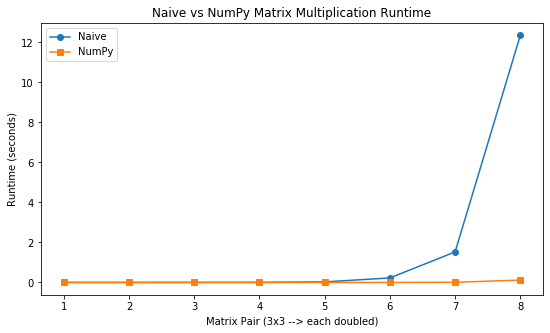

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, 9), naive_times, marker='o', label='Naive')
plt.plot(range(1, 9), numpy_times, marker='s', label='NumPy')
plt.title('Naive vs NumPy Matrix Multiplication Runtime')
plt.xlabel('Matrix Pair (3x3 --> each doubled)')
plt.ylabel('Runtime (seconds)')
plt.legend()
plt.show()